# f_large first gridsearch

Plot als 'thesis_plot_dmft.pdf' gespeichert.


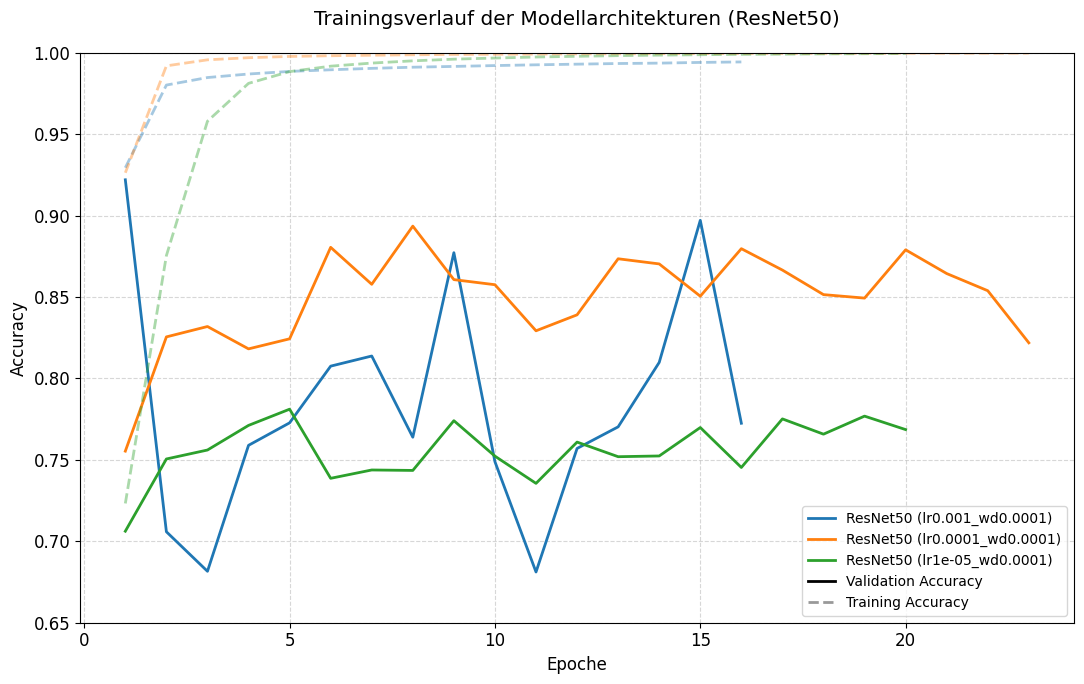

In [13]:
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# --- KONFIGURATION ---
# Doppelte Pfade wurden hier entfernt
MODEL_PATHS = [
    "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_grid_08_01_01_new/DM_time_binary_classificator_resnet50_dropout0.0-ft_100_15/lr0.001_wd0.0001",
    "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_grid_08_01_01_new/DM_time_binary_classificator_resnet50_dropout0.0-ft_100_15/lr0.0001_wd0.0001",
    "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs_grid_08_01_01_new/DM_time_binary_classificator_resnet50_dropout0.0-ft_100_15/lr1e-05_wd0.0001",
]

# Style-Einstellungen für die Masterarbeit
plt.rcParams.update({
    'font.size': 12, 
    'lines.linewidth': 2.0,
    'axes.prop_cycle': plt.cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']) # Schöne Farbpalette
})

def get_label_from_path(path):
    parts = path.strip("/").split("/")
    if len(parts) >= 2:
        params = parts[-1]      
        model_part = parts[-2]  
        
        model_name = "ResNet18" if "resnet18" in model_part else "ResNet50"
        if "GAP" in model_part: model_name = "6-GAP"
        
        return f"{model_name} ({params})"
    return path

def plot_selected_models(paths):
    plt.figure(figsize=(11, 7))
    
    # Speichert die Handles für die Farben
    color_handles = []
    
    for path in paths:
        if not os.path.exists(path):
            print(f"Warnung: Pfad existiert nicht: {path}")
            continue
            
        train_path = os.path.join(path, "Accuracy_train")
        val_path = os.path.join(path, "Accuracy_val")
        
        if not os.path.exists(train_path) or not os.path.exists(val_path):
            print(f"Accuracy-Unterordner nicht gefunden für: {path}")
            continue

        ea_train = EventAccumulator(train_path)
        ea_train.Reload()
        ea_val = EventAccumulator(val_path)
        ea_val.Reload()
        
        tags_train = ea_train.Tags().get('scalars', [])
        tags_val = ea_val.Tags().get('scalars', [])
        
        if 'Accuracy' in tags_train and 'Accuracy' in tags_val:
            label = get_label_from_path(path)
            
            train_ev = ea_train.Scalars('Accuracy')
            val_ev = ea_val.Scalars('Accuracy')
            
            steps_train = [e.step for e in train_ev]
            train_values = [e.value for e in train_ev]
            steps_val = [e.step for e in val_ev]
            val_values = [e.value for e in val_ev]
            
            # Plot Validation (Durchgezogen) - Das P in p[0] speichert das Linien-Objekt
            p = plt.plot(steps_val, val_values, linestyle='-', label=label)
            color = p[0].get_color() # Farbe abgreifen
            
            # Plot Train (Gestrichelt, transparent, selbe Farbe)
            plt.plot(steps_train, train_values, color=color, linestyle='--', alpha=0.4)
        else:
            print(f"Tags nicht gefunden in den Unterordnern von: {path}")

    plt.title("Trainingsverlauf der Modellarchitekturen (ResNet50)", pad=20)
    plt.xlabel("Epoche")
    plt.ylabel("Accuracy")
    import numpy as np
    plt.ylim(0.65, 1.0)
    #plt.yticks(np.arange(0.7, 1.05, 0.05)) # Zwingt Ticks exakt bei 0.70, 0.75, 0.80 ... 1.00
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    
    # --- Die verbesserte Legende bauen ---
    handles, labels = plt.gca().get_legend_handles_labels()
    
    # Füge zwei Dummy-Linien hinzu, um die Linienstile (Train vs Val) zu erklären
    style_handles = [
        Line2D([0], [0], color='black', linestyle='-', linewidth=2, label='Validation Accuracy'),
        Line2D([0], [0], color='black', linestyle='--', alpha=0.4, linewidth=2, label='Training Accuracy')
    ]
    
    # Kombiniere die Modell-Farben mit den Linienstilen in einer Legende
    plt.legend(handles=handles + style_handles, loc='lower right', fontsize='small', frameon=True)
    
    plt.tight_layout()
    plt.savefig("thesis_plot_dmft.pdf") 
    print("Plot als 'thesis_plot_dmft.pdf' gespeichert.")
    plt.show()

if __name__ == "__main__":
    plot_selected_models(MODEL_PATHS)